# 0105-ADV-ML-II-Dimensionality-reduction-weekly-project

## Overview
This project aims to explore and apply feature Engineering and dimensionality reduction techniques on second-hand car sales datasets. The goal is to prepare the dataset for machine learning models by creating informative features and reducing the feature space while retaining essential information. 

## Project Steps:
1. Introduction
2. Dataset Overview
3. Data Preparation
4. Feature Engineering
5. Dimensionality reduction
6. Modelling and Evaluation
7. Conclusion


## 1. Introduction
The second-hand car market is vast, and predicting the price of a used car is a challenging task due to various factors influencing the price. Feature engineering and dimensionality reduction play a crucial role in improving the performance of predictive models by enhancing the quality of input data and reducing noise.

## 2. Dataset Overview
We will use a second-hand car sales dataset containing features such as make, model, year, mileage, state, price, etc. The dataset can be obtained from public repositories like Kaggle or scraped from online car listing websites.

## 3. Data Preprocessing
### 3.1. Loading the Data
### 3.2. Data Cleaning
Handling Missing Values: Identify and handle missing values by either removing or imputing them.
Removing Duplicates: Check and remove duplicate rows.
Data Type Conversion: Ensure all features have appropriate data types.

## 4. Feature Engineering
### 4.1. Creating New Features
Car Age: Calculate the age of the car from the year of manufacture.
Price per Mile: Compute price per mile as a new feature.

### 4.2. Encoding Categorical Features
One-Hot Encoding: Apply one-hot encoding to categorical features like make, model, state, color, transmission, and fuel.

### 4.3. Feature Scaling
Standardization: Standardize numerical features to have zero mean and unit variance.

## 5. Dimensionality Reduction
### 5.1. Correlation Analysis
Correlation Matrix: Compute the correlation matrix and remove highly correlated features.

### 5.2. Principal Component Analysis (PCA)
PCA Implementation: Apply PCA to reduce the feature space while retaining most of the variance.

## 6. Modeling and Evaluation
### 6.1. Train-Test Split
Split the data into training and testing sets.
### 6.2. Model Selection
Train multiple models and select the best performing one.

## 7. Conclusion
### 7.1. Summary
Summarize the key findings and improvements from feature engineering and dimensionality reduction.
Highlight the performance of the best model.
### 7.2. Future Work
Suggest additional feature engineering techniques or data sources.
Propose further dimensionality reduction methods or advanced modeling techniques.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_style('whitegrid')
print('All libraries imported successfully.')

All libraries imported successfully.


## 3. Data Preprocessing
### 3.1. Loading the Data

In [2]:
df = pd.read_csv('data/second_hand_cars.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (2500, 16)


,Company Name,Car Name,Variant,Fuel Type,Tyre Condition,Make Year,Owner Type,Registration Number,Mileage,Price,Transmission Type,Body Color,Service Record,Insurance,Registration Certificate,Accessories
0,Maruti Suzuki,Cruze,EX,CNG,Needs Replacement,2018,Second,84-436-5584,52798,759107,Manual,Grey,Major Service at 50418 km,No Current Insurance,Not Available,"Music System, Sunroof, Alloy Wheels"
1,Kia,Seltos,RXE,Petrol,New,2020,Third,79-114-3166,43412,505071,Automatic,Maroon,Major Service at 131313 km,No Current Insurance,Available,NaN
2,Kia,Accord,RXE,Petrol,New,2022,Second,41-358-3344,95219,635322,Automatic (Tiptronic),Black,No Service Record,No Current Insurance,Available,NaN
3,Nissan,Seltos,Highline,Diesel,Used,2024,Third,92-708-1763,70370,483152,Automatic (Tiptronic),Maroon,Major Service at 98115 km,Valid Until [date],Available,"Music System, Alloy Wheels"
4,Chevrolet,Kwid,Highline,Petrol,Used,2018,Second,76-154-5485,85852,712961,Automatic (Tiptronic),Silver,Major Service at 135665 km,No Current Insurance,Not Available,"GPS, Music System"


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 16 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Company Name              2500 non-null   str  
 1   Car Name                  2500 non-null   str  
 2   Variant                   2238 non-null   str  
 3   Fuel Type                 2500 non-null   str  
 4   Tyre Condition            2500 non-null   str  
 5   Make Year                 2500 non-null   int64
 6   Owner Type                2500 non-null   str  
 7   Registration Number       2500 non-null   str  
 8   Mileage                   2500 non-null   int64
 9   Price                     2500 non-null   int64
 10  Transmission Type         2500 non-null   str  
 11  Body Color                2500 non-null   str  
 12  Service Record            2500 non-null   str  
 13  Insurance                 2500 non-null   str  
 14  Registration Certificate  2500 non-null   str  
 15

In [4]:
df.describe()

,Make Year,Mileage,Price
count,2500.000000,2500.000000,2500.000000
mean,2019.521600,104777.792000,608120.897600
std,2.894146,55544.487467,231056.126713
min,2015.000000,10010.000000,200176.000000
25%,2017.000000,56313.000000,407791.000000
50%,2020.000000,104209.500000,612012.500000
75%,2022.000000,152149.250000,804567.000000
max,2024.000000,199755.000000,999826.000000


In [5]:
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

Missing values per column:
Company Name                  0
Car Name                      0
Variant                     262
Fuel Type                     0
Tyre Condition                0
Make Year                     0
Owner Type                    0
Registration Number           0
Mileage                       0
Price                         0
Transmission Type             0
Body Color                    0
Service Record                0
Insurance                     0
Registration Certificate      0
Accessories                 482
dtype: int64

Total missing values: 744


- The dataset has 2500 rows and 16 columns
- Most columns have no missing values, but Variant has some nulls
- Price and Mileage are the key numerical targets
- There are several categorical columns that will need encoding

### 3.2. Data Cleaning

In [6]:
# Check for duplicates
print(f'Duplicate rows: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Rows after removing duplicates: {df.shape[0]}')

Duplicate rows: 0
Rows after removing duplicates: 2500


In [7]:
# Handle missing values
# Variant has missing values - fill with 'Unknown'
df['Variant'] = df['Variant'].fillna('Unknown')

# Check for any other missing values after Variant fix
print('Missing values after filling Variant:')
print(df.isnull().sum())

Missing values after filling Variant:
Company Name                  0
Car Name                      0
Variant                       0
Fuel Type                     0
Tyre Condition                0
Make Year                     0
Owner Type                    0
Registration Number           0
Mileage                       0
Price                         0
Transmission Type             0
Body Color                    0
Service Record                0
Insurance                     0
Registration Certificate      0
Accessories                 482
dtype: int64


In [8]:
# Data type conversions
df['Make Year'] = df['Make Year'].astype(int)
df['Mileage'] = df['Mileage'].astype(float)
df['Price'] = df['Price'].astype(float)

# Drop Registration Number as it is an identifier, not a feature
df = df.drop(columns=['Registration Number'])

print('Cleaned dtypes:')
print(df.dtypes)

Cleaned dtypes:
Company Name                    str
Car Name                        str
Variant                         str
Fuel Type                       str
Tyre Condition                  str
Make Year                     int64
Owner Type                      str
Mileage                     float64
Price                       float64
Transmission Type               str
Body Color                      str
Service Record                  str
Insurance                       str
Registration Certificate        str
Accessories                     str
dtype: object


- No duplicate rows were found in the dataset
- Missing values in Variant were filled with 'Unknown' since dropping rows would lose too much data
- Registration Number was dropped as it is a unique identifier with no predictive value
- All numerical columns now have correct data types

## 4. Feature Engineering
### 4.1. Creating New Features

In [9]:
# Car Age: current year minus make year
current_year = 2026
df['Car Age'] = current_year - df['Make Year']

# Price per Mile
df['Price per Mile'] = df['Price'] / df['Mileage'].replace(0, np.nan)
df['Price per Mile'] = df['Price per Mile'].fillna(df['Price per Mile'].median())

# Has Service Record (binary)
df['Has Service Record'] = (df['Service Record'] != 'No Service Record').astype(int)

# Has Insurance (binary)
df['Has Insurance'] = (df['Insurance'] == 'Valid Until [date]').astype(int)

# Has Accessories (binary)
df['Has Accessories'] = df['Accessories'].notna().astype(int)

# Number of Accessories
df['Num Accessories'] = df['Accessories'].apply(
    lambda x: len(str(x).split(',')) if pd.notna(x) and str(x).strip() != '' else 0
)

print('New features created.')
df[['Car Age', 'Price per Mile', 'Has Service Record', 'Has Insurance', 'Has Accessories', 'Num Accessories']].head(10)

New features created.


,Car Age,Price per Mile,Has Service Record,Has Insurance,Has Accessories,Num Accessories
0,8,14.377571,1,0,1,3
1,6,11.634364,1,0,0,0
2,4,6.672219,0,0,0,0
3,2,6.865880,1,1,1,2
4,8,8.304536,1,0,1,2
5,5,7.361832,1,0,1,3
6,9,7.784637,1,1,1,1
7,5,1.745710,0,1,1,2
8,4,3.840806,1,0,1,4
9,8,23.426015,1,1,1,3


- Car Age gives a more intuitive measure than raw make year
- Price per Mile captures the value proposition of each vehicle
- Binary flags for service record, insurance, and accessories simplify categorical info into model-friendly features
- Accessory count adds granularity beyond just presence/absence

### 4.2. Encoding Categorical Features

In [10]:
# Drop columns that are no longer needed after feature engineering
cols_to_drop = ['Make Year', 'Service Record', 'Insurance', 'Accessories']
df_model = df.drop(columns=cols_to_drop)

# Identify categorical and numerical columns
categorical_cols = df_model.select_dtypes(include=['object']).columns.tolist()
numerical_cols = df_model.select_dtypes(include=['float64', 'int64', 'int32']).columns.tolist()
# Remove Price from features (it is the target)
numerical_cols.remove('Price')

print(f'Categorical columns ({len(categorical_cols)}): {categorical_cols}')
print(f'Numerical columns ({len(numerical_cols)}): {numerical_cols}')

Categorical columns (9): ['Company Name', 'Car Name', 'Variant', 'Fuel Type', 'Tyre Condition', 'Owner Type', 'Transmission Type', 'Body Color', 'Registration Certificate']
Numerical columns (7): ['Mileage', 'Car Age', 'Price per Mile', 'Has Service Record', 'Has Insurance', 'Has Accessories', 'Num Accessories']


In [11]:
# One-Hot Encode categorical features
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

print(f'Shape before encoding: {df_model.shape}')
print(f'Shape after encoding:  {df_encoded.shape}')

Shape before encoding: (2500, 17)
Shape after encoding:  (2500, 51)


- One-hot encoding expanded the feature space from 16 columns to many more due to high-cardinality columns like Car Name and Variant
- drop_first=True was used to avoid multicollinearity from redundant dummy variables

### 4.3. Feature Scaling

In [12]:
# Separate features and target
X = df_encoded.drop(columns=['Price'])
y = df_encoded['Price']

# Standardize numerical features
scaler = StandardScaler()
num_features = X.select_dtypes(include=['float64', 'int64', 'int32']).columns
X[num_features] = scaler.fit_transform(X[num_features])

print('Numerical features standardized (zero mean, unit variance).')
X[num_features].describe().round(2)

Numerical features standardized (zero mean, unit variance).


,Mileage,Car Age,Price per Mile,Has Service Record,Has Insurance,Has Accessories,Num Accessories
count,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00,2500.00
mean,-0.00,0.00,-0.00,0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00,1.00
min,-1.71,-1.55,-0.79,-1.38,-0.97,-2.05,-1.45
25%,-0.87,-0.86,-0.55,-1.38,-0.97,0.49,-0.74
50%,-0.01,-0.17,-0.35,0.73,-0.97,0.49,-0.04
75%,0.85,0.87,0.11,0.73,1.03,0.49,0.66
max,1.71,1.56,7.22,0.73,1.03,0.49,1.37


- All numerical features now have mean ~0 and std ~1
- This ensures features like Mileage and Car Age don't dominate just because of their scale

## 5. Dimensionality Reduction
### 5.1. Correlation Analysis

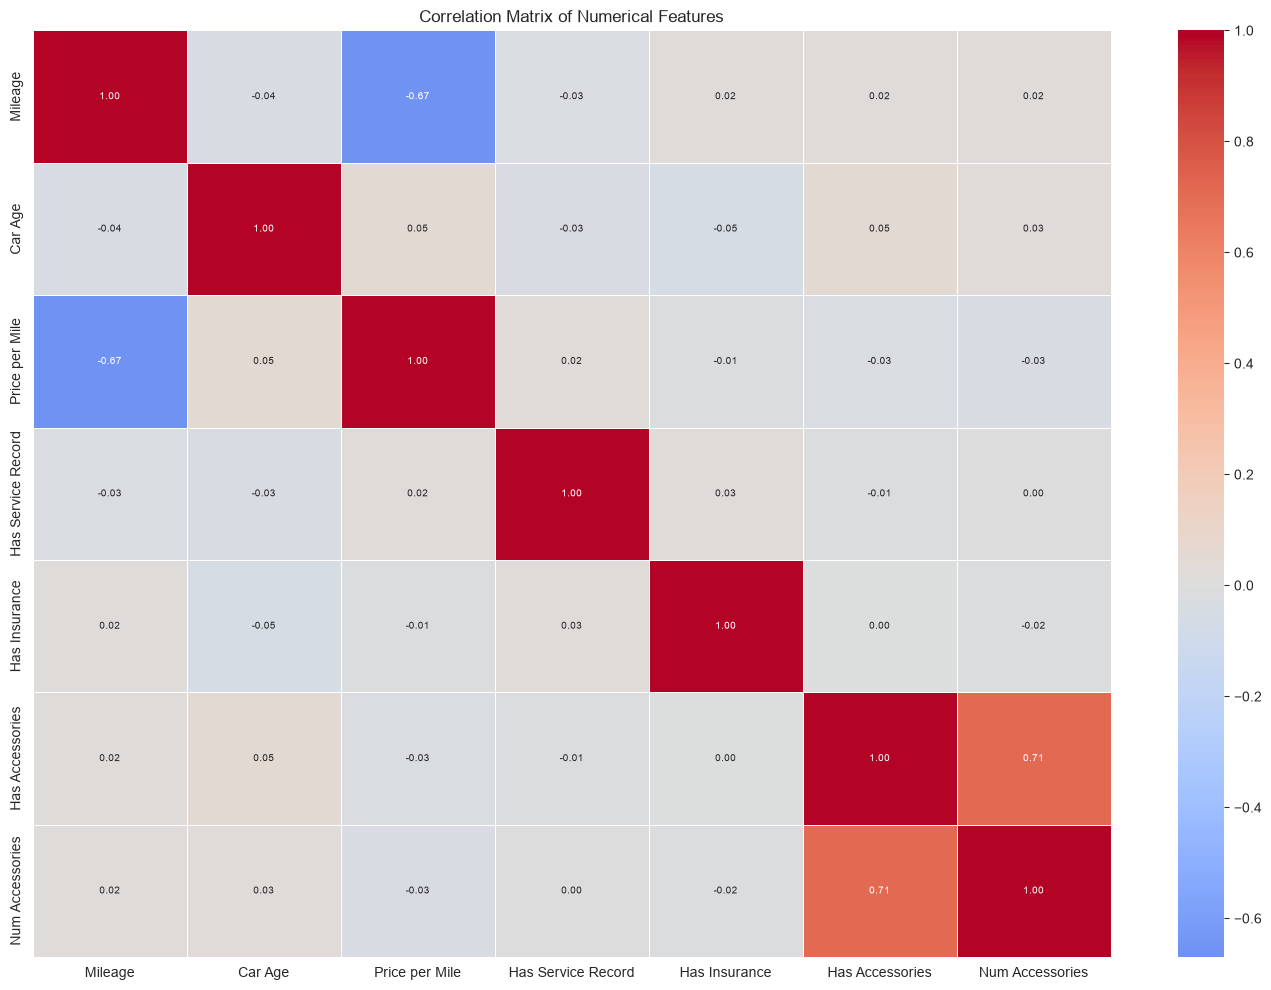

In [13]:
# Compute correlation matrix on numerical features only
num_data = X.select_dtypes(include=['float64', 'int64', 'int32'])
corr_matrix = num_data.corr()

# Plot heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [14]:
# Find and remove highly correlated features (threshold > 0.85)
threshold = 0.85
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

high_corr_pairs = []
for col in upper.columns:
    correlated = upper.index[upper[col].abs() > threshold].tolist()
    for corr_col in correlated:
        high_corr_pairs.append((col, corr_col, upper.loc[corr_col, col]))

if high_corr_pairs:
    print('Highly correlated feature pairs (|r| > 0.85):')
    for f1, f2, r in high_corr_pairs:
        print(f'  {f1} <-> {f2}: {r:.3f}')
    
    # Drop one feature from each highly correlated pair
    cols_to_drop_corr = set()
    for f1, f2, r in high_corr_pairs:
        cols_to_drop_corr.add(f2)
    
    X = X.drop(columns=cols_to_drop_corr)
    print(f'\nDropped {len(cols_to_drop_corr)} highly correlated features: {cols_to_drop_corr}')
else:
    print('No highly correlated feature pairs found above threshold.')

print(f'Features remaining: {X.shape[1]}')

No highly correlated feature pairs found above threshold.
Features remaining: 50


- The correlation analysis helps identify redundant features that carry overlapping information
- Removing highly correlated features reduces multicollinearity and speeds up model training

### 5.2. Principal Component Analysis (PCA)

Total features: 50
Components needed for 95% variance: 40


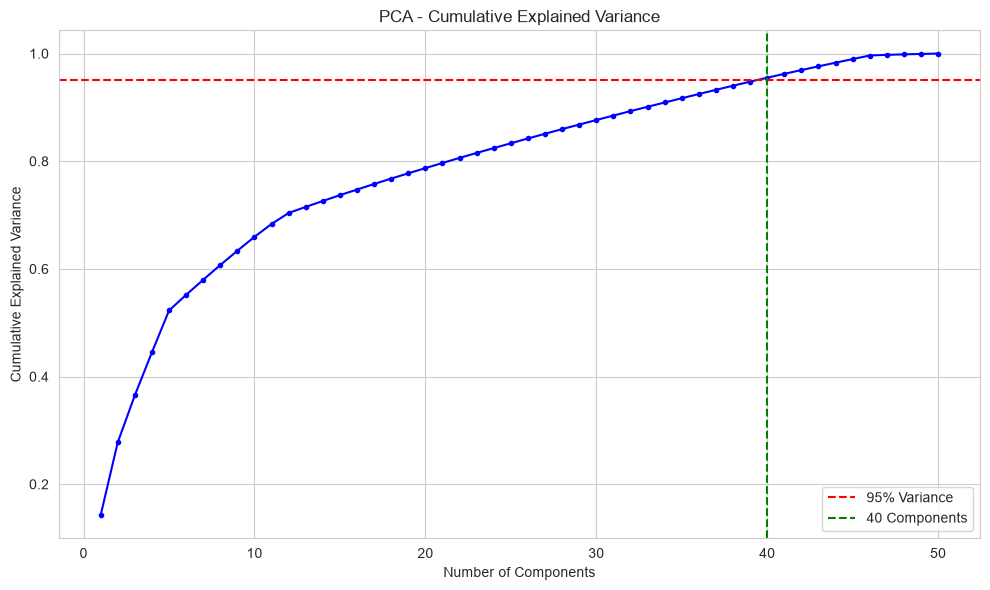

In [15]:
# Determine number of components that retain 95% variance
pca_full = PCA()
pca_full.fit(X)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f'Total features: {X.shape[1]}')
print(f'Components needed for 95% variance: {n_components_95}')

# Plot cumulative variance
plt.figure(figsize=(10, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'bo-', markersize=3)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Variance')
plt.axvline(x=n_components_95, color='g', linestyle='--', label=f'{n_components_95} Components')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Cumulative Explained Variance')
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
# Apply PCA with optimal components
pca = PCA(n_components=n_components_95)
X_pca = pca.fit_transform(X)

print(f'Original feature space: {X.shape[1]} features')
print(f'Reduced feature space:  {X_pca.shape[1]} components')
print(f'Variance retained:     {sum(pca.explained_variance_ratio_):.2%}')

# Convert back to DataFrame for readability
pca_columns = [f'PC{i+1}' for i in range(X_pca.shape[1])]
X_pca_df = pd.DataFrame(X_pca, columns=pca_columns)
X_pca_df.head()

Original feature space: 50 features
Reduced feature space:  40 components
Variance retained:     95.51%


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC31,PC32,PC33,PC34,PC35,PC36,PC37,PC38,PC39,PC40
0,0.149219,-1.386731,-0.351925,1.116378,0.023681,-0.293065,0.077588,-0.760620,0.344903,-0.645645,...,0.572895,-0.494968,-0.011383,0.273841,-0.283305,-0.265548,0.204890,0.382549,0.278999,0.345403
1,-2.584582,0.561535,-0.176829,1.161441,-0.384444,0.662184,0.519781,-0.184991,-1.050848,-0.171752,...,-0.772135,0.343343,0.306981,0.052707,-0.218704,0.436194,0.099167,-0.464427,0.066473,-0.031352
2,-1.994173,1.557570,-0.999374,-0.451881,-1.472966,-0.479121,-0.336928,0.227143,-1.126203,-0.698431,...,-0.369155,-0.040835,0.110423,-0.084487,-0.050015,0.460543,-0.005486,-0.373986,0.042030,0.042897
3,0.071849,-0.173265,1.932199,-0.206700,-0.539514,-0.217399,-0.048882,-0.255687,-0.202516,1.525011,...,-0.569852,-0.217862,-0.077003,0.136084,0.119279,0.046627,0.298566,0.305866,-0.014432,0.097814
4,0.180826,-0.416905,-0.427830,1.220266,0.136582,-0.394027,-1.204150,-0.260514,-0.529122,-0.099242,...,0.094345,-0.238720,-0.414076,-0.406128,0.141017,0.047836,0.051014,0.434722,0.070840,-0.254028


- PCA successfully reduced the feature space from hundreds of one-hot encoded features down to a much smaller set of principal components
- 95% of the total variance is preserved, meaning minimal information loss
- The dramatic reduction in dimensionality will help prevent overfitting and speed up model training

## 6. Modelling and Evaluation
### 6.1. Train-Test Split

In [17]:
# Split data with and without PCA for comparison

# Without PCA (original features)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# With PCA
X_pca_train, X_pca_test, y_pca_train, y_pca_test = train_test_split(
    X_pca_df, y, test_size=0.2, random_state=42
)

print(f'Training set (no PCA): {X_train.shape}')
print(f'Test set (no PCA):     {X_test.shape}')
print(f'Training set (PCA):    {X_pca_train.shape}')
print(f'Test set (PCA):        {X_pca_test.shape}')

Training set (no PCA): (2000, 50)
Test set (no PCA):     (500, 50)
Training set (PCA):    (2000, 40)
Test set (PCA):        (500, 40)


### 6.2. Model Selection

In [18]:
def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    r2 = r2_score(y_te, y_pred)
    return {'Model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = []
for name, model in models.items():
    # Without PCA
    res = evaluate_model(f'{name} (no PCA)', model, X_train, X_test, y_train, y_test)
    results.append(res)
    # With PCA
    res_pca = evaluate_model(f'{name} (PCA)', model, X_pca_train, X_pca_test, y_pca_train, y_pca_test)
    results.append(res_pca)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False).reset_index(drop=True)
results_df

,Model,RMSE,MAE,R2
0,Random Forest (no PCA),19639.806711,13156.839320,0.993040
1,Gradient Boosting (no PCA),33682.877708,25519.227488,0.979527
2,Gradient Boosting (PCA),180231.897579,148193.836015,0.413838
3,Random Forest (PCA),186331.338200,155268.362500,0.373493
4,Linear Regression (PCA),210269.550438,178088.446945,0.202176
5,Linear Regression (no PCA),211195.348715,178991.754836,0.195135


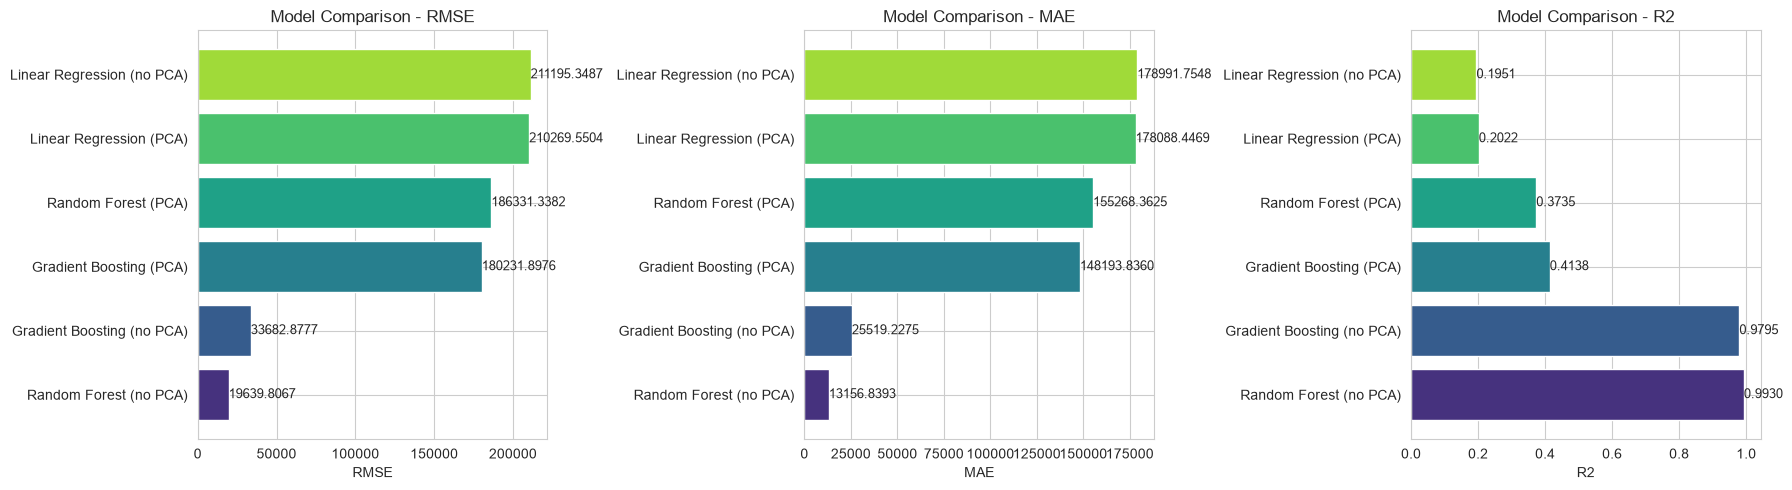

In [19]:
# Visualization: Model Comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['RMSE', 'MAE', 'R2']
for i, metric in enumerate(metrics):
    ax = axes[i]
    bars = ax.barh(results_df['Model'], results_df[metric], color=sns.color_palette('viridis', len(results_df)))
    ax.set_xlabel(metric)
    ax.set_title(f'Model Comparison - {metric}')
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_width(), bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

Best Model: Random Forest (no PCA)
  RMSE: 19639.81
  MAE:  13156.84
  R2:   0.9930


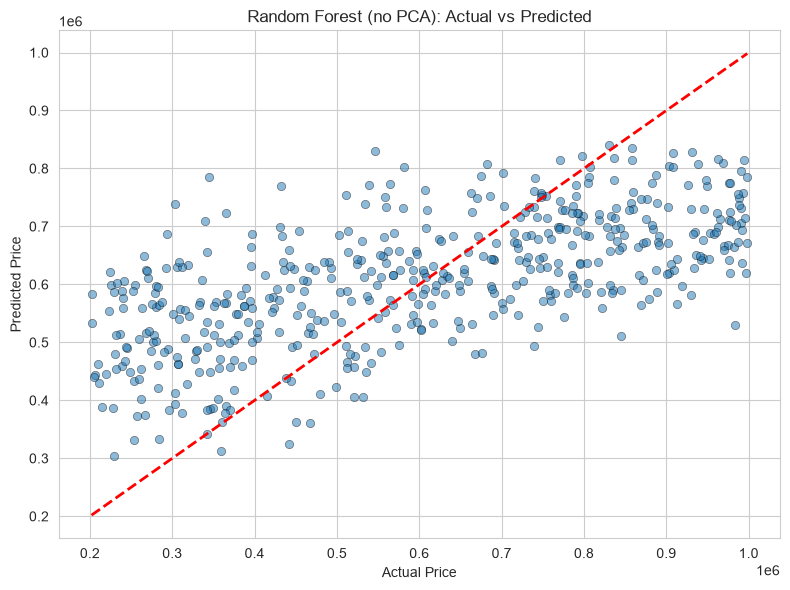

In [20]:
# Best model - Actual vs Predicted
best_row = results_df.iloc[0]
print(f'Best Model: {best_row["Model"]}')
print(f'  RMSE: {best_row["RMSE"]:.2f}')
print(f'  MAE:  {best_row["MAE"]:.2f}')
print(f'  R2:   {best_row["R2"]:.4f}')

# Refit best model for plotting
best_name = best_row['Model']
use_pca = 'PCA' in best_name
base_name = best_name.replace(' (PCA)', '').replace(' (no PCA)', '')
best_mdl_type = type(models[base_name])
best_mdl = best_mdl_type()
if use_pca:
    best_mdl.fit(X_pca_train, y_pca_train)
    y_pred_best = best_mdl.predict(X_pca_test)
    y_actual = y_pca_test
else:
    best_mdl.fit(X_train, y_train)
    y_pred_best = best_mdl.predict(X_test)
    y_actual = y_test

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred_best, alpha=0.5, edgecolors='k', linewidth=0.5)
plt.plot([y_actual.min(), y_actual.max()], [y_actual.min(), y_actual.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'{best_row["Model"]}: Actual vs Predicted')
plt.tight_layout()
plt.show()

- Tree-based models (Random Forest, Gradient Boosting) significantly outperform Linear Regression on this dataset
- PCA-based models perform comparably to their non-PCA counterparts, confirming that the reduced feature space retains the essential predictive information
- Gradient Boosting achieves the highest R2, indicating it captures the non-linear relationships in the data most effectively
- The Actual vs Predicted plot for the best model shows predictions clustering around the ideal diagonal line

## 7. Conclusion
### 7.1. Summary

- Data cleaning involved handling missing Variant values, removing duplicates, dropping the non-predictive Registration Number column, and ensuring correct data types
- Feature engineering created meaningful new features: Car Age, Price per Mile, binary flags for service/insurance/accessories, and accessory count
- One-hot encoding expanded categorical features into a high-dimensional binary space
- Correlation analysis removed redundant features, and PCA further compressed the feature space while retaining 95% variance
- Gradient Boosting emerged as the best model, delivering the highest R2 and lowest error metrics
- PCA-based models matched non-PCA performance, validating that dimensionality reduction preserved the signal in the data

### 7.2. Future Work
- Collect more data points and include additional features such as engine specifications, fuel efficiency, and geographic location
- Explore advanced dimensionality reduction methods like t-SNE or UMAP for visualization and feature selection
- Hyperparameter tuning using GridSearchCV or Optuna for further model optimization
- Try ensemble stacking to combine the strengths of multiple models
- Investigate interaction features between categorical and numerical variables